In [6]:
import pandas as pd
import networkx as nx
import pickle

In [7]:
columns=['UNIPROT_SOURCE', 'ENTREZ_SOURCE', 'UNIPROT_TARGET', 'ENTREZ_TARGET', 'CONFIDENCE_SCORE', 'EXPERIMENT_DETAILS']
ppi_df = pd.read_csv("./hippie_current.txt", sep='\t', header=None, names=columns,)
ppi = ppi_df.dropna()
ppi

,UNIPROT_SOURCE,ENTREZ_SOURCE,UNIPROT_TARGET,ENTREZ_TARGET,CONFIDENCE_SCORE,EXPERIMENT_DETAILS
1,AL1A1_HUMAN,216.0,AL1A1_HUMAN,216.0,0.76,"experiments:in vivo,Two-hybrid;pmids:12081471,..."
2,ITA7_HUMAN,3679.0,ACHA_HUMAN,1134.0,0.73,"experiments:in vivo,Affinity Capture-Western,a..."
3,NEB1_HUMAN,55607.0,ACTG_HUMAN,71.0,0.78,"experiments:in vitro,in vivo,cross-linking stu..."
4,SRGN_HUMAN,5552.0,CD44_HUMAN,960.0,0.63,"experiments:in vivo;pmids:9334256,16189514,167..."
5,GRB7_HUMAN,2886.0,ERBB2_HUMAN,2064.0,0.90,"experiments:in vitro,in vivo,Reconstituted Com..."
...,...,...,...,...,...,...
1118995,NUP43_HUMAN,348995.0,SRS10_HUMAN,10772.0,0.63,experiments:bioid;pmids:37689310;sources:BioGRID
1118996,MYCN_HUMAN,4613.0,GTF2I_HUMAN,2969.0,0.63,experiments:affinity chromatography technology...
1118997,PCNT_HUMAN,5116.0,K1468_HUMAN,57614.0,0.63,experiments:cross-linking study;pmids:40437099...
1118998,MYCN_HUMAN,4613.0,TF3C2_HUMAN,2976.0,0.63,experiments:affinity chromatography technology...


In [8]:
node_names = set(ppi['UNIPROT_SOURCE'].unique()) | set(ppi['UNIPROT_TARGET'].unique())
len(node_names)
node_name_map = {node_name:i for i,node_name in enumerate(node_names)}
ppi['UNIPROT_SOURCE_index'] = ppi['UNIPROT_SOURCE'].apply(lambda x: node_name_map[x])
ppi['UNIPROT_TARGET_index'] = ppi['UNIPROT_TARGET'].apply(lambda x: node_name_map[x])
ppi['relation'] = ['ppi']*len(ppi)
ppi

,UNIPROT_SOURCE,ENTREZ_SOURCE,UNIPROT_TARGET,ENTREZ_TARGET,CONFIDENCE_SCORE,EXPERIMENT_DETAILS,UNIPROT_SOURCE_index,UNIPROT_TARGET_index,relation
1,AL1A1_HUMAN,216.0,AL1A1_HUMAN,216.0,0.76,"experiments:in vivo,Two-hybrid;pmids:12081471,...",5258,5258,ppi
2,ITA7_HUMAN,3679.0,ACHA_HUMAN,1134.0,0.73,"experiments:in vivo,Affinity Capture-Western,a...",7592,12402,ppi
3,NEB1_HUMAN,55607.0,ACTG_HUMAN,71.0,0.78,"experiments:in vitro,in vivo,cross-linking stu...",4238,11732,ppi
4,SRGN_HUMAN,5552.0,CD44_HUMAN,960.0,0.63,"experiments:in vivo;pmids:9334256,16189514,167...",10204,13449,ppi
5,GRB7_HUMAN,2886.0,ERBB2_HUMAN,2064.0,0.90,"experiments:in vitro,in vivo,Reconstituted Com...",6081,12700,ppi
...,...,...,...,...,...,...,...,...,...
1118995,NUP43_HUMAN,348995.0,SRS10_HUMAN,10772.0,0.63,experiments:bioid;pmids:37689310;sources:BioGRID,6297,691,ppi
1118996,MYCN_HUMAN,4613.0,GTF2I_HUMAN,2969.0,0.63,experiments:affinity chromatography technology...,4274,18600,ppi
1118997,PCNT_HUMAN,5116.0,K1468_HUMAN,57614.0,0.63,experiments:cross-linking study;pmids:40437099...,3222,9912,ppi
1118998,MYCN_HUMAN,4613.0,TF3C2_HUMAN,2976.0,0.63,experiments:affinity chromatography technology...,4274,2971,ppi


In [8]:
source_nodes = ppi[['UNIPROT_SOURCE_index','UNIPROT_SOURCE', 'ENTREZ_SOURCE']].copy()
source_nodes.columns = ["id", "name",'Entrez']

target_nodes = ppi[['UNIPROT_TARGET_index','UNIPROT_TARGET', 'ENTREZ_TARGET']].copy()
target_nodes.columns = ["id", "name",'Entrez']

nodes = pd.concat([source_nodes, target_nodes])

# Remove duplicates
nodes = nodes.drop_duplicates(subset=["id"])

# Neo4j label cleanup
nodes["label"] = ['Protein']*len(nodes)

# neo4j formatting
nodes = nodes.rename(columns={
    "id": "id:ID",
    "name": "name",
    "label": ":LABEL",
    'Entrez':'Entrez'
})
nodes.to_csv("./import/nodes.csv", index=False)
nodes

,id:ID,name,Entrez,:LABEL
1,7019,AL1A1_HUMAN,216.0,Protein
2,2667,ITA7_HUMAN,3679.0,Protein
3,8999,NEB1_HUMAN,55607.0,Protein
4,1974,SRGN_HUMAN,5552.0,Protein
5,3589,GRB7_HUMAN,2886.0,Protein
...,...,...,...,...
1110178,2686,O2AE1_HUMAN,81392.0,Protein
1113461,16036,P1L12_HUMAN,285877.0,Protein
1113796,7286,MARHB_HUMAN,441061.0,Protein
1114870,13721,CAN14_HUMAN,440854.0,Protein


In [10]:
# Build edge table
# --------------------------------------------------
edges = ppi[["UNIPROT_SOURCE_index", "relation", "UNIPROT_TARGET_index",'CONFIDENCE_SCORE', 'EXPERIMENT_DETAILS']].copy()

edges.columns = [":START_ID", ":TYPE", ":END_ID",'CONFIDENCE_SCORE', 'EXPERIMENT_DETAILS']

# Neo4j relationship formatting
edges[":TYPE"] = (
    edges[":TYPE"]
    .str.upper()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)
edges.to_csv("./import/edges.csv", index=False)

print("Done.")
print(f"Nodes: {len(nodes)}")
print(f"Edges: {len(edges)}")
edges

Done.
Nodes: 18809
Edges: 1105119


,:START_ID,:TYPE,:END_ID,CONFIDENCE_SCORE,EXPERIMENT_DETAILS
1,7019,PPI,7019,0.76,"experiments:in vivo,Two-hybrid;pmids:12081471,..."
2,2667,PPI,14168,0.73,"experiments:in vivo,Affinity Capture-Western,a..."
3,8999,PPI,3358,0.78,"experiments:in vitro,in vivo,cross-linking stu..."
4,1974,PPI,9239,0.63,"experiments:in vivo;pmids:9334256,16189514,167..."
5,3589,PPI,6746,0.90,"experiments:in vitro,in vivo,Reconstituted Com..."
...,...,...,...,...,...
1118995,3940,PPI,10927,0.63,experiments:bioid;pmids:37689310;sources:BioGRID
1118996,2225,PPI,15195,0.63,experiments:affinity chromatography technology...
1118997,4755,PPI,9496,0.63,experiments:cross-linking study;pmids:40437099...
1118998,2225,PPI,6665,0.63,experiments:affinity chromatography technology...


### Save PPIKG (confidence >= 0.7)

In [9]:
ppi_hc = ppi[ppi['CONFIDENCE_SCORE']>= 0.7]
#ppi_hc.to_csv('ppi_hc.csv', index=False)

To networkx

In [10]:
def ppi_triples_to_nx(df, output=None, remove_isolated_nodes=False):
    G = nx.MultiDiGraph()
    for i, row in df.iterrows():
        G.add_node(row['UNIPROT_SOURCE'], Entrez_ID=row['ENTREZ_SOURCE'])
        G.add_node(row['UNIPROT_TARGET'], Entrez_ID=row['ENTREZ_TARGET'])
        G.add_edge(u_for_edge=row['UNIPROT_SOURCE'], v_for_edge=row['UNIPROT_TARGET'],
                rel='PPI',
                confidence=row['CONFIDENCE_SCORE'],
                evidence=row['EXPERIMENT_DETAILS'])

    print(f"Added {G.number_of_nodes()} nodes and {G.number_of_edges()} edges to graph G")
    
    if remove_isolated_nodes:
        nodes_to_keep = [
            node for node in G.nodes() 
            if any(neighbor != node for neighbor in G.neighbors(node))
        ]
        cleaned_G = G.subgraph(nodes_to_keep).copy()
        print(f"Cleaned G has {cleaned_G.number_of_nodes()} nodes and {cleaned_G.number_of_edges()} edges")
        G = cleaned_G
        
    if output:
        with open(output,'wb') as f:
            pickle.dump(G,f)
    
    return G

In [11]:
G_hc = ppi_triples_to_nx(ppi_hc, remove_isolated_nodes=True)
G_ppi = ppi_triples_to_nx(ppi, remove_isolated_nodes=True)

Added 17042 nodes and 382526 edges to graph G
Cleaned G has 14628 nodes and 353269 edges
Added 18809 nodes and 1105119 edges to graph G
Cleaned G has 17252 nodes and 1088365 edges


In [12]:
for node in G_ppi.nodes():
    print(node)
    pr_name = node.split("_")[0]
    print(pr_name)
    break

AL1A1_HUMAN
AL1A1


## KG proteins vs. GE proteins

In [15]:
adni_exp = pd.read_csv("../data/ADNI/cleaned_gene_expression_data.csv", index_col=0)
ge_df = adni_exp.T

In [16]:
ge_df

gene,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
116_S_1249,3.651,2.2865,3.039,2.3395,2.783,2.0565,2.081,7.043,3.30950,2.202,...,3.77150,4.0365,2.988,4.353000,4.739500,1.9045,5.31750,9.2190,7.3010,5.7490
037_S_4410,3.183,2.1230,3.543,2.2085,2.383,2.3490,1.733,6.773,3.27625,2.317,...,4.17300,4.4415,3.471,4.520667,4.702333,1.9265,5.38800,8.3785,6.7580,6.0935
006_S_4153,3.278,2.3545,3.528,2.1745,2.593,2.5260,1.841,6.910,3.20875,2.540,...,3.91275,4.6210,2.967,4.230667,4.545333,2.2315,5.62800,9.1085,7.3365,5.2615
116_S_1232,3.371,2.3725,3.835,2.1545,2.570,2.4720,2.249,7.209,3.24950,2.559,...,3.73800,4.4435,3.207,4.050667,4.562500,2.0545,5.46300,9.3210,7.1685,4.7340
099_S_4205,3.358,2.3865,3.392,2.1720,2.660,2.2965,1.893,6.920,3.15425,2.347,...,3.94600,4.5215,3.611,4.639667,4.890667,2.0405,5.64750,9.0300,7.2025,5.4575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
009_S_2381,3.302,2.5075,3.524,2.2525,2.876,2.8380,2.089,6.805,3.09150,2.650,...,3.50150,4.4685,2.770,3.962333,4.472167,1.9320,5.44275,9.2900,6.7035,4.7915
053_S_4557,3.403,2.3090,3.515,2.3225,3.106,2.7715,2.102,7.265,3.27575,2.603,...,3.58325,4.1555,3.081,4.125667,4.609833,1.9445,5.14000,9.8090,7.2810,4.7055
073_S_4300,3.530,2.4155,3.651,2.0760,2.707,2.3280,2.092,7.375,3.26950,2.557,...,3.63450,4.5165,3.051,4.070333,4.733500,2.0795,5.38775,9.5215,6.9825,5.0785
041_S_4014,3.532,2.4545,3.609,2.3495,3.081,2.8230,2.024,7.257,3.11425,2.497,...,3.68525,4.0480,3.304,3.976333,4.091000,2.0075,5.05725,9.5810,6.6865,3.8660


In [19]:
G_ppi = ppi_triples_to_nx(ppi, remove_isolated_nodes=False)

Added 18809 nodes and 1105119 edges to graph G


In [20]:
ge_proteins = set(ge_df.columns)
kg_proteins = set(node.split("_")[0] for node in G_ppi.nodes())

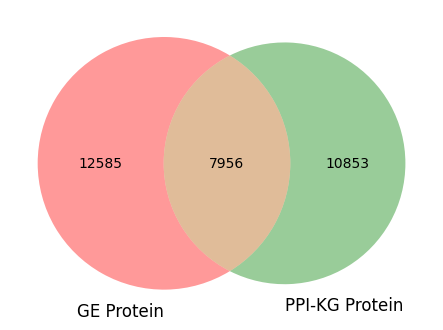

In [21]:
from matplotlib_venn import *
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
venn2(subsets=(ge_proteins,kg_proteins),
      set_labels=('GE Protein','PPI-KG Protein'),)
plt.show()

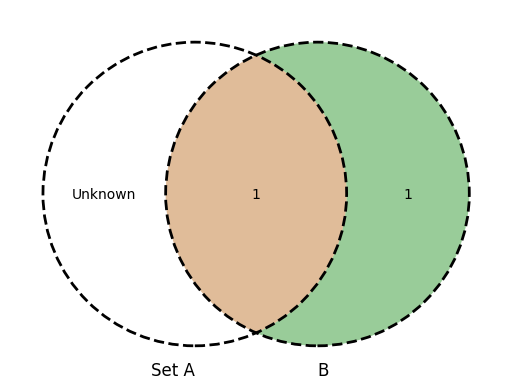

In [36]:
v = venn2(subsets={'10': 1, '01': 1, '11': 1}, set_labels = ('A', 'B'))
c = venn2_circles(subsets=(1, 1, 1), linestyle='dashed')
v.get_patch_by_id('10').set_alpha(1.0)
v.get_patch_by_id('10').set_color('white')
v.get_label_by_id('10').set_text('Unknown')
v.get_label_by_id('A').set_text('Set A')

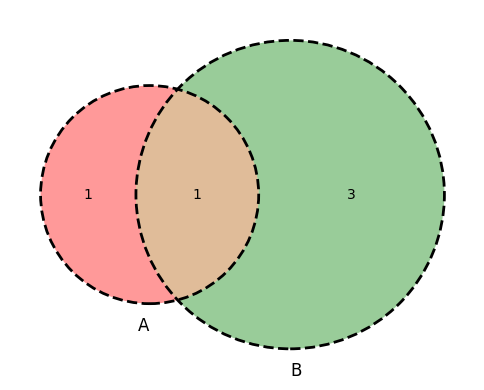

In [35]:
v = venn2(subsets=(set([1,2]), set([2,3,4,5])), 
          set_labels = ('A', 'B')) 
c = venn2_circles(subsets=(set([1,2]), set([2,3,4,5])), 
                  linestyle='dashed') 
# print("%0.2f" % (v.get_circle_radius(1)/v.get_circle_radius(0))) 

## String_high_confidence

In [17]:
df_hc = pd.read_csv("../CLEP_PPIKG_neo4j/string_high_confidence_ppi.txt", sep=' ')
df_hc

,protein1,protein2,combined_score
0,9606.ENSP00000000233,9606.ENSP00000158762,825
1,9606.ENSP00000000233,9606.ENSP00000357048,718
2,9606.ENSP00000000233,9606.ENSP00000262305,952
3,9606.ENSP00000000233,9606.ENSP00000329419,752
4,9606.ENSP00000000233,9606.ENSP00000469035,795
...,...,...,...
473855,9606.ENSP00000501277,9606.ENSP00000326630,942
473856,9606.ENSP00000501277,9606.ENSP00000263726,944
473857,9606.ENSP00000501317,9606.ENSP00000290524,780
473858,9606.ENSP00000501317,9606.ENSP00000305071,978


In [21]:
from pybiomart import Dataset

# Fetch data directly from Ensembl human dataset
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

# Query to match Ensembl Protein IDs to HGNC/Gene Symbols
results = dataset.query(
    attributes=['ensembl_peptide_id', 'hgnc_symbol']
)

# Convert to a mapping dictionary
mapping_df = pd.DataFrame(results)
mapping_df['string_id'] = "9606." + mapping_df['Protein stable ID']
id_to_symbol = dict(zip(mapping_df['string_id'], mapping_df['HGNC symbol']))

# Example lookup
print(id_to_symbol.get("9606.ENSP00000000233"))

ARF5


In [30]:
results

,Protein stable ID,HGNC symbol
0,NaN,MT-TF
1,NaN,MT-RNR1
2,NaN,MT-TV
3,NaN,MT-RNR2
4,NaN,MT-TL1
...,...,...
280546,ENSP00000642607,YY1AP1
280547,ENSP00000642608,YY1AP1
280548,ENSP00000642609,YY1AP1
280549,ENSP00000642610,YY1AP1


In [24]:
mapping_df

,Protein stable ID,HGNC symbol,string_id
0,NaN,MT-TF,NaN
1,NaN,MT-RNR1,NaN
2,NaN,MT-TV,NaN
3,NaN,MT-RNR2,NaN
4,NaN,MT-TL1,NaN
...,...,...,...
280546,ENSP00000642607,YY1AP1,9606.ENSP00000642607
280547,ENSP00000642608,YY1AP1,9606.ENSP00000642608
280548,ENSP00000642609,YY1AP1,9606.ENSP00000642609
280549,ENSP00000642610,YY1AP1,9606.ENSP00000642610


In [29]:
new_triples = []
x = 0
for i, row in df_hc.iterrows():
    string_1 = row['protein1']
    string_2 = row['protein2']
    score = row['combined_score']
    src = id_to_symbol.get(string_1)
    dst = id_to_symbol.get(string_2)
    if src is not None and dst is not None:
        new_triples.append({'Protein1':src, 'Protein2':dst, 'Score':score})
    else:
        print(string_1, src)
        print(string_2, dst)
        print()
        x +=1
        
new_df = pd.DataFrame(new_triples)

9606.ENSP00000000233 ARF5
9606.ENSP00000440005 None

9606.ENSP00000005178 PDK4
9606.ENSP00000369134 None

9606.ENSP00000005257 RALA
9606.ENSP00000499717 None

9606.ENSP00000005260 BAIAP2L1
9606.ENSP00000497733 None

9606.ENSP00000005587 SKAP2
9606.ENSP00000477713 None

9606.ENSP00000006053 CX3CL1
9606.ENSP00000474412 None

9606.ENSP00000006053 CX3CL1
9606.ENSP00000292301 None

9606.ENSP00000006275 TRAPPC6A
9606.ENSP00000485615 None

9606.ENSP00000006275 TRAPPC6A
9606.ENSP00000373979 None

9606.ENSP00000008391 TFAP2D
9606.ENSP00000501092 None

9606.ENSP00000009105 CAMK1G
9606.ENSP00000264773 None

9606.ENSP00000009105 CAMK1G
9606.ENSP00000499797 None

9606.ENSP00000009530 CD74
9606.ENSP00000376055 None

9606.ENSP00000009530 CD74
9606.ENSP00000413436 None

9606.ENSP00000009530 CD74
9606.ENSP00000474412 None

9606.ENSP00000009530 CD74
9606.ENSP00000423067 None

9606.ENSP00000009530 CD74
9606.ENSP00000438788 None

9606.ENSP00000011292 CPA1
9606.ENSP00000501111 None

9606.ENSP00000011653 CD

In [27]:
new_df

,Protein1,Protein2,Score
0,ARF5,ACAP1,825
1,ARF5,COPA,718
2,ARF5,RAB11FIP3,952
3,ARF5,COPB2,752
4,ARF5,COPE,795
...,...,...,...
473855,LDB1,ZFPM1,942
473856,LDB1,LHX4,944
473857,NaN,RFX5,780
473858,NaN,RFXANK,978


In [22]:
string_ids = df_hc['protein1'].to_list() + df_hc['protein2'].to_list()
print(f"The number of src, dst nodes: {len(string_ids)}")
print(f"The number of unique proteins: {len(set(string_ids))}")

The number of src, dst nodes: 947720
The number of unique proteins: 16201
